In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_path = Path("../MichenkowResults")

distribution_heads = ["Normal", "StudentT", "SkewedStudentT", "BLogistic"]
model_specs = ["NoReg", "NoReg_RV", "NoReg_RV_Decay"]
layer_sizes = [[128, 64, 32], [64, 32, 16], [64, 32], [128, 64], [32, 16]]

results = {}

for head in distribution_heads:
    for spec in model_specs:
        for layer in layer_sizes:
            layer_str = "-".join(list(map(lambda x: str(x), layer)))
            file_path = base_path / f"{head}{spec}_{layer_str}" / "final_losses.csv"
            df = pd.read_csv(file_path)
            print(df)
            results[(head, spec)] = df

print("Loaded:", len(results), "models")



  data_type      loss  loss_std
0     train  1.000276  0.002732
1       dev  0.988306  0.004151
2      test  0.999116  0.003794
  data_type      loss  loss_std
0     train  1.007224  0.002707
1       dev  0.992414  0.004074
2      test  1.006325  0.003810
  data_type      loss  loss_std
0     train  1.006477  0.002715
1       dev  0.992046  0.004043
2      test  1.004154  0.003765
  data_type      loss  loss_std
0     train  1.002933  0.002701
1       dev  0.991010  0.004184
2      test  1.001444  0.003749
  data_type      loss  loss_std
0     train  1.012103  0.002740
1       dev  0.996818  0.004051
2      test  1.010999  0.003874
  data_type      loss  loss_std
0     train  0.991262  0.002471
1       dev  0.977832  0.004176
2      test  0.989583  0.003509
  data_type      loss  loss_std
0     train  0.991407  0.002471
1       dev  0.978227  0.004138
2      test  0.989354  0.003496
  data_type      loss  loss_std
0     train  0.992063  0.002431
1       dev  0.979007  0.004095
2      t

In [7]:
import pandas as pd
from pathlib import Path

base_path = Path("../MichenkowResults")

distribution_heads = ["Normal", "StudentT", "SkewedStudentT", "BLogistic"]
model_specs = ["NoReg", "NoReg_RV", "NoReg_RV_Decay"]
layer_sizes = [
    [128, 64, 32],
    [64, 32, 16],
    [64, 32],
    [128, 64],
    [32, 16]
]

def layer_to_str(layer):
    return "-".join(map(str, layer))

results = {}

for head in distribution_heads:
    for spec in model_specs:
        table = pd.DataFrame()

        for layer in layer_sizes:
            layer_str = layer_to_str(layer)
            file_path = base_path / f"{head}{spec}_{layer_str}" / "final_losses.csv"

            if not file_path.exists():
                continue

            df = pd.read_csv(file_path)

            # df has rows train/dev/test
            # We want column = layer_str
            table[layer_str] = df.set_index("data_type")["loss"]
            table.index.name = None

        # store result table for this head & spec
        results[(head, spec)] = table

        print(f"\n===== {head} {spec} =====")
        display(table)



===== Normal NoReg =====


,128-64-32,64-32-16,64-32,128-64,32-16
train,1.000276,1.007224,1.006477,1.002933,1.012103
dev,0.988306,0.992414,0.992046,0.991010,0.996818
test,0.999116,1.006325,1.004154,1.001444,1.010999



===== Normal NoReg_RV =====


,128-64-32,64-32-16,64-32,128-64,32-16
train,0.991262,0.991407,0.992063,0.989188,0.993628
dev,0.977832,0.978227,0.979007,0.977363,0.979827
test,0.989583,0.989354,0.990118,0.987996,0.992180



===== Normal NoReg_RV_Decay =====


...

,128-64-32,64-32-16,64-32,128-64,32-16
train,0.966683,0.969430,0.969551,0.966558,0.976096
dev,0.955910,0.958490,0.958408,0.955772,0.964263
test,0.969326,0.971547,0.971648,0.969293,0.978424



===== BLogistic NoReg_RV =====


,128-64-32,64-32-16,64-32,128-64,32-16
train,0.958678,0.961899,0.962157,0.959987,0.964773
dev,0.947995,0.950586,0.950990,0.949016,0.953313
test,0.961856,0.964438,0.964956,0.962929,0.967221



===== BLogistic NoReg_RV_Decay =====


,128-64-32,64-32-16,64-32,128-64,32-16
train,0.957453,0.959919,0.959913,0.958010,0.961797
dev,0.947220,0.948744,0.948732,0.947477,0.950447
test,0.961112,0.962190,0.962428,0.961765,0.963637


In [11]:
def label_name(head, spec):
    if spec == "NoReg":
        return f"{head}, Past Returns"
    elif spec == "NoReg_RV":
        return f"{head}, Past Returns + Realized Variance"
    elif spec == "NoReg_RV_Decay":
        return f"{head}, Past Returns + Realized Variance + Time Elapse"

    raise ValueError(f"Unknown model spec: {spec}")


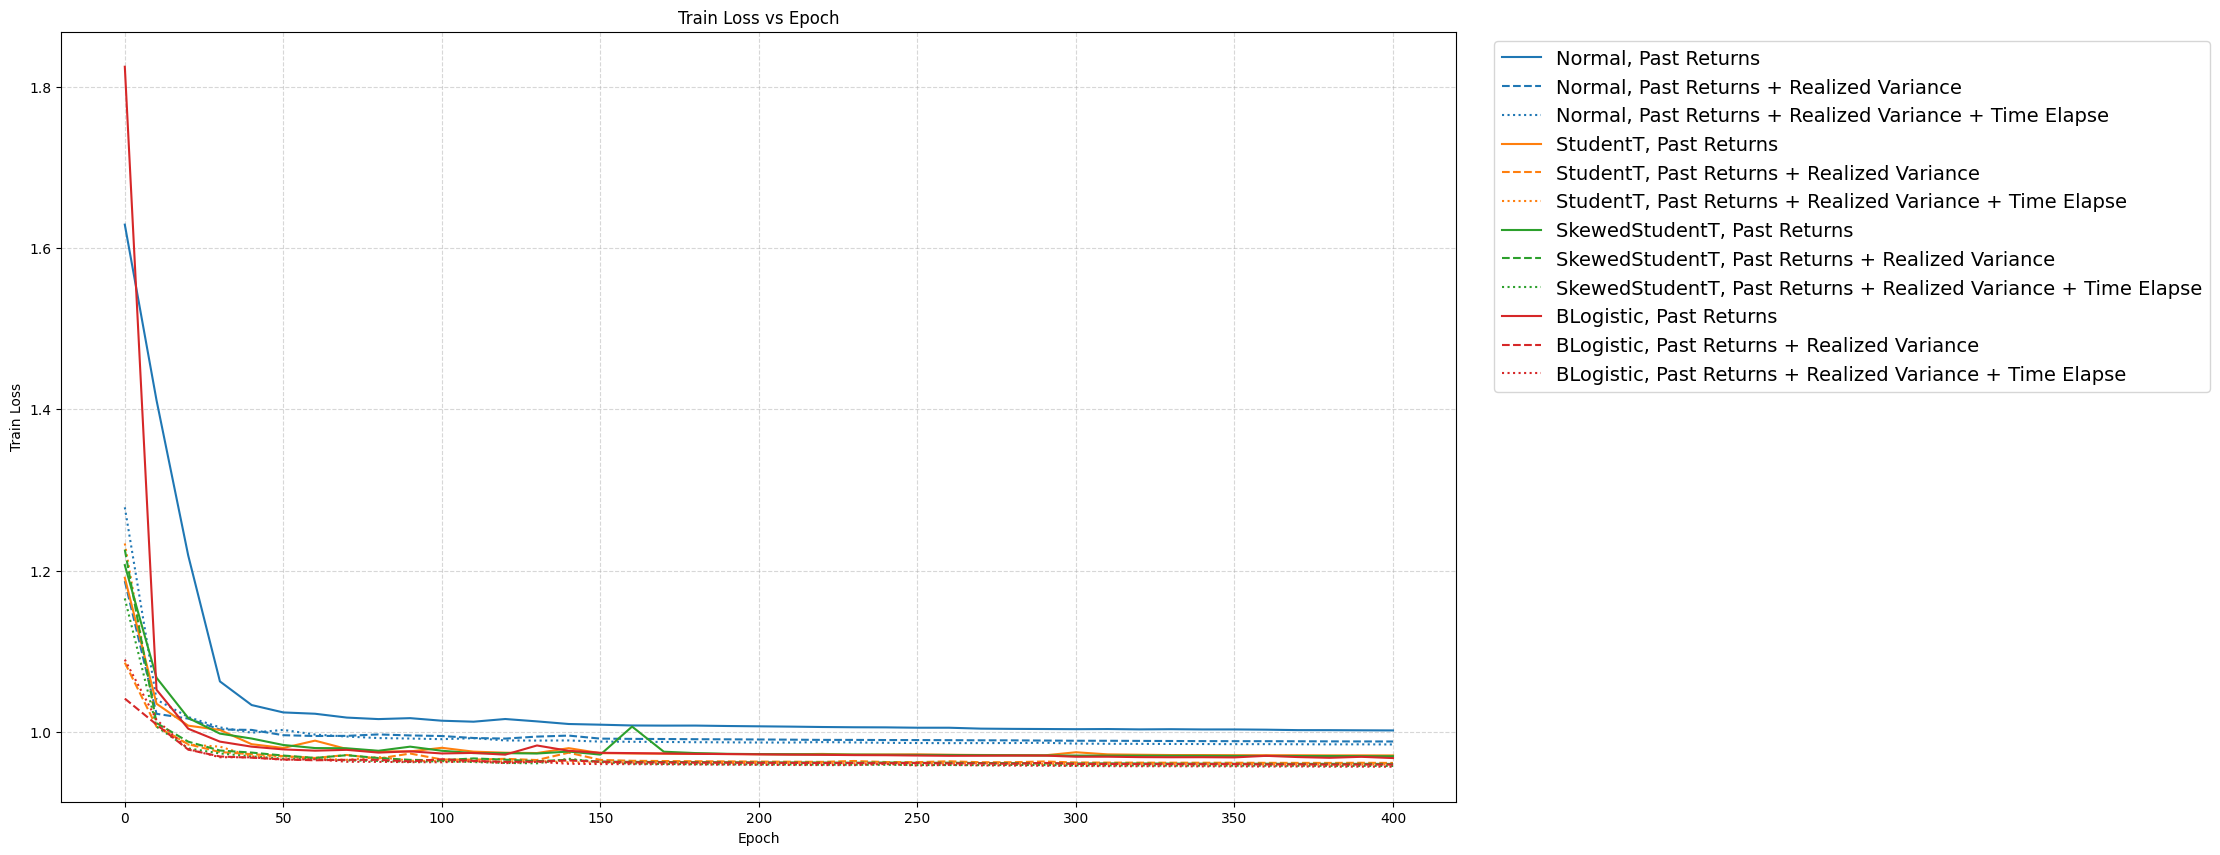

In [20]:
plt.figure(figsize=(18, 10))
plt.title("Train Loss vs Epoch")

for (head, spec), df in results.items():
    color = color_map[head]
    style = style_map[spec]

    plt.plot(
        df["epoch"], df["train_loss"],
        label=label_name(head, spec),
        color=color,
        linestyle=style
    )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=14
)
plt.show()


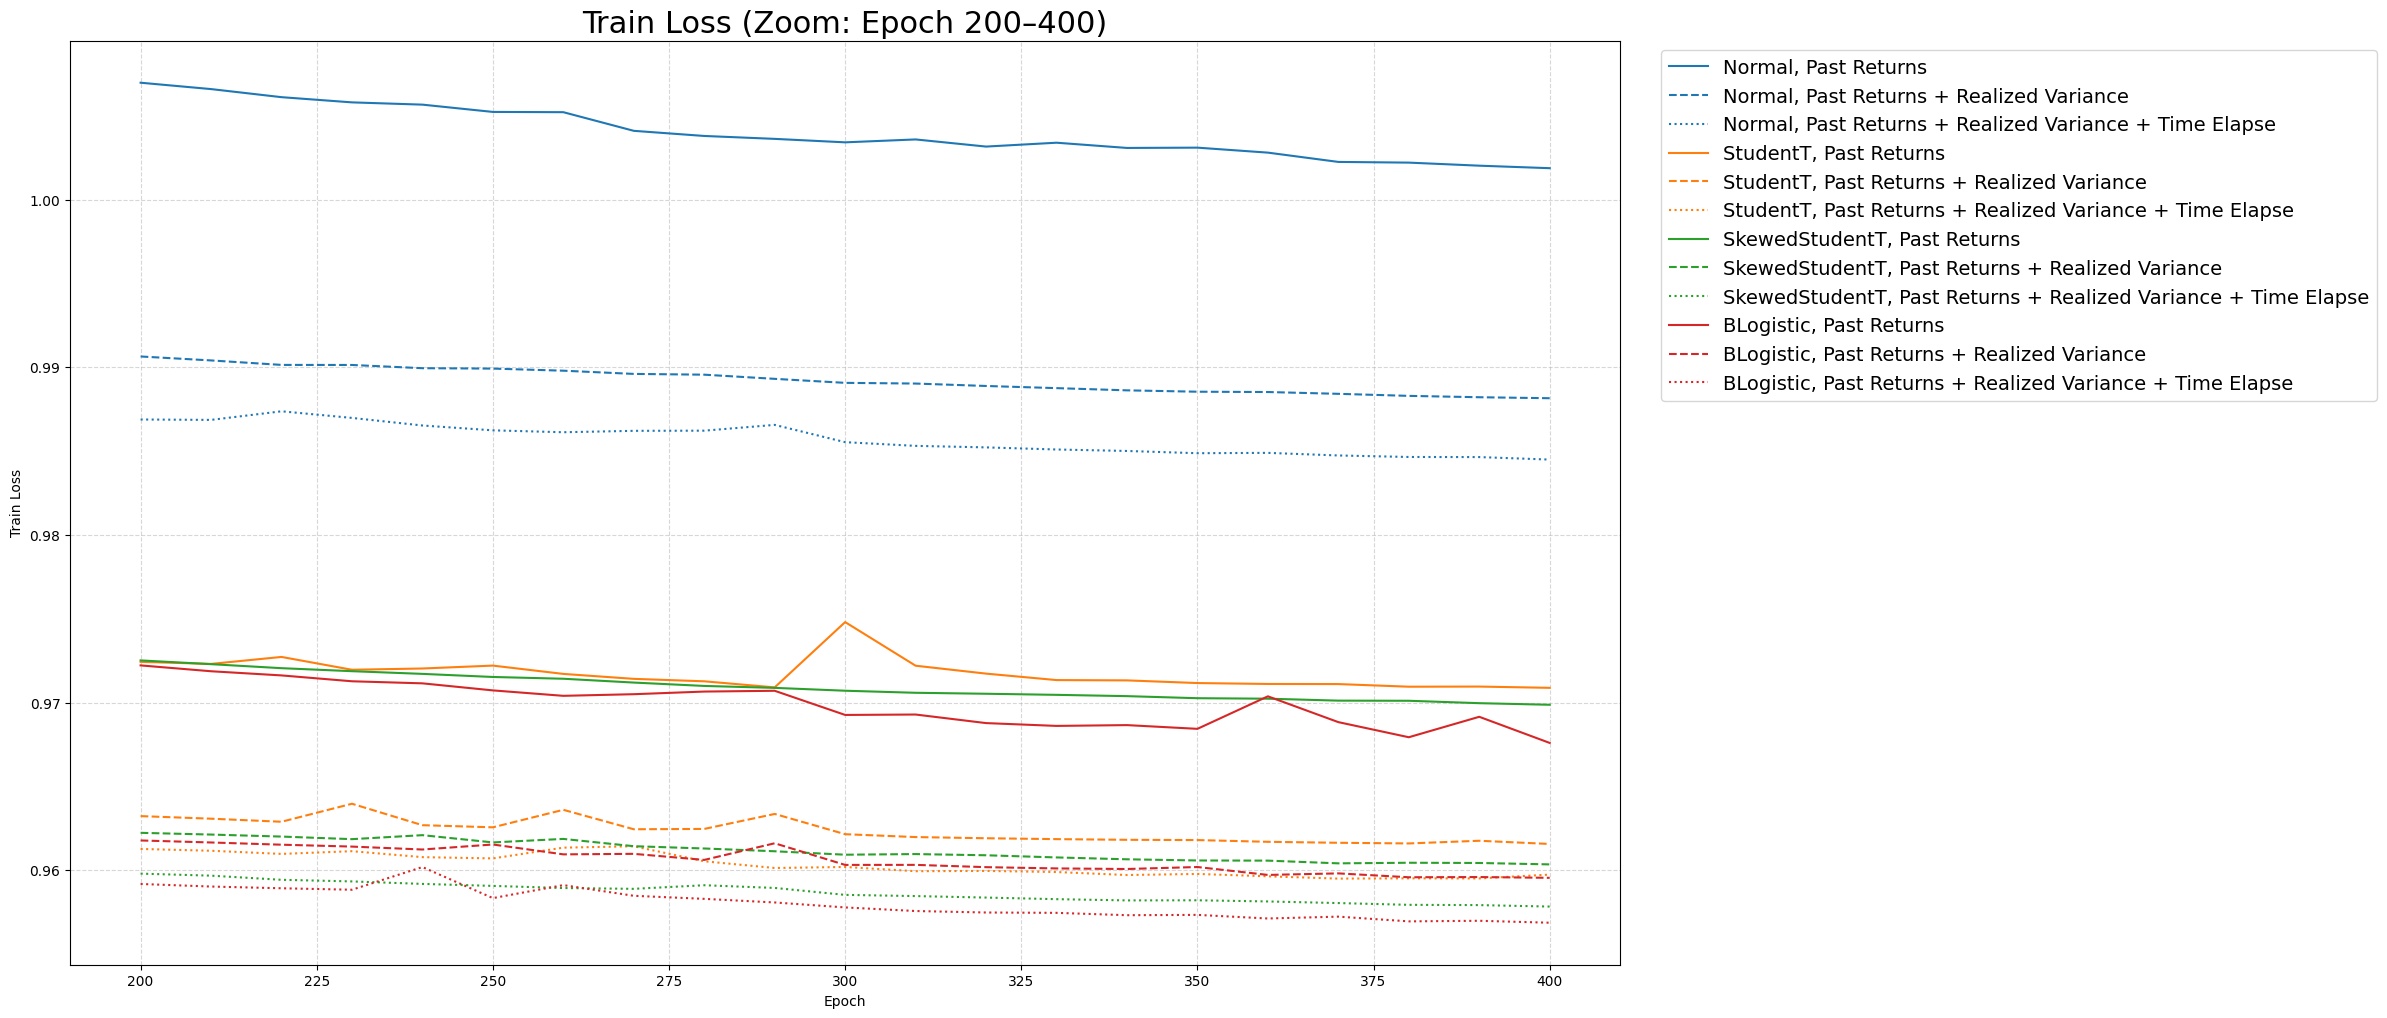

In [19]:
plt.figure(figsize=(20, 12))
plt.title("Train Loss (Zoom: Epoch 200–400)", fontsize=22)

for (head, spec), df in results.items():
    color = color_map[head]
    style = style_map[spec]

    zoom_df = df[(df["epoch"] >= 200) & (df["epoch"] <= 400)]

    plt.plot(
        zoom_df["epoch"], zoom_df["train_loss"],
        label=label_name(head, spec),
        color=color,
        linestyle=style
    )

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=14
)
plt.show()


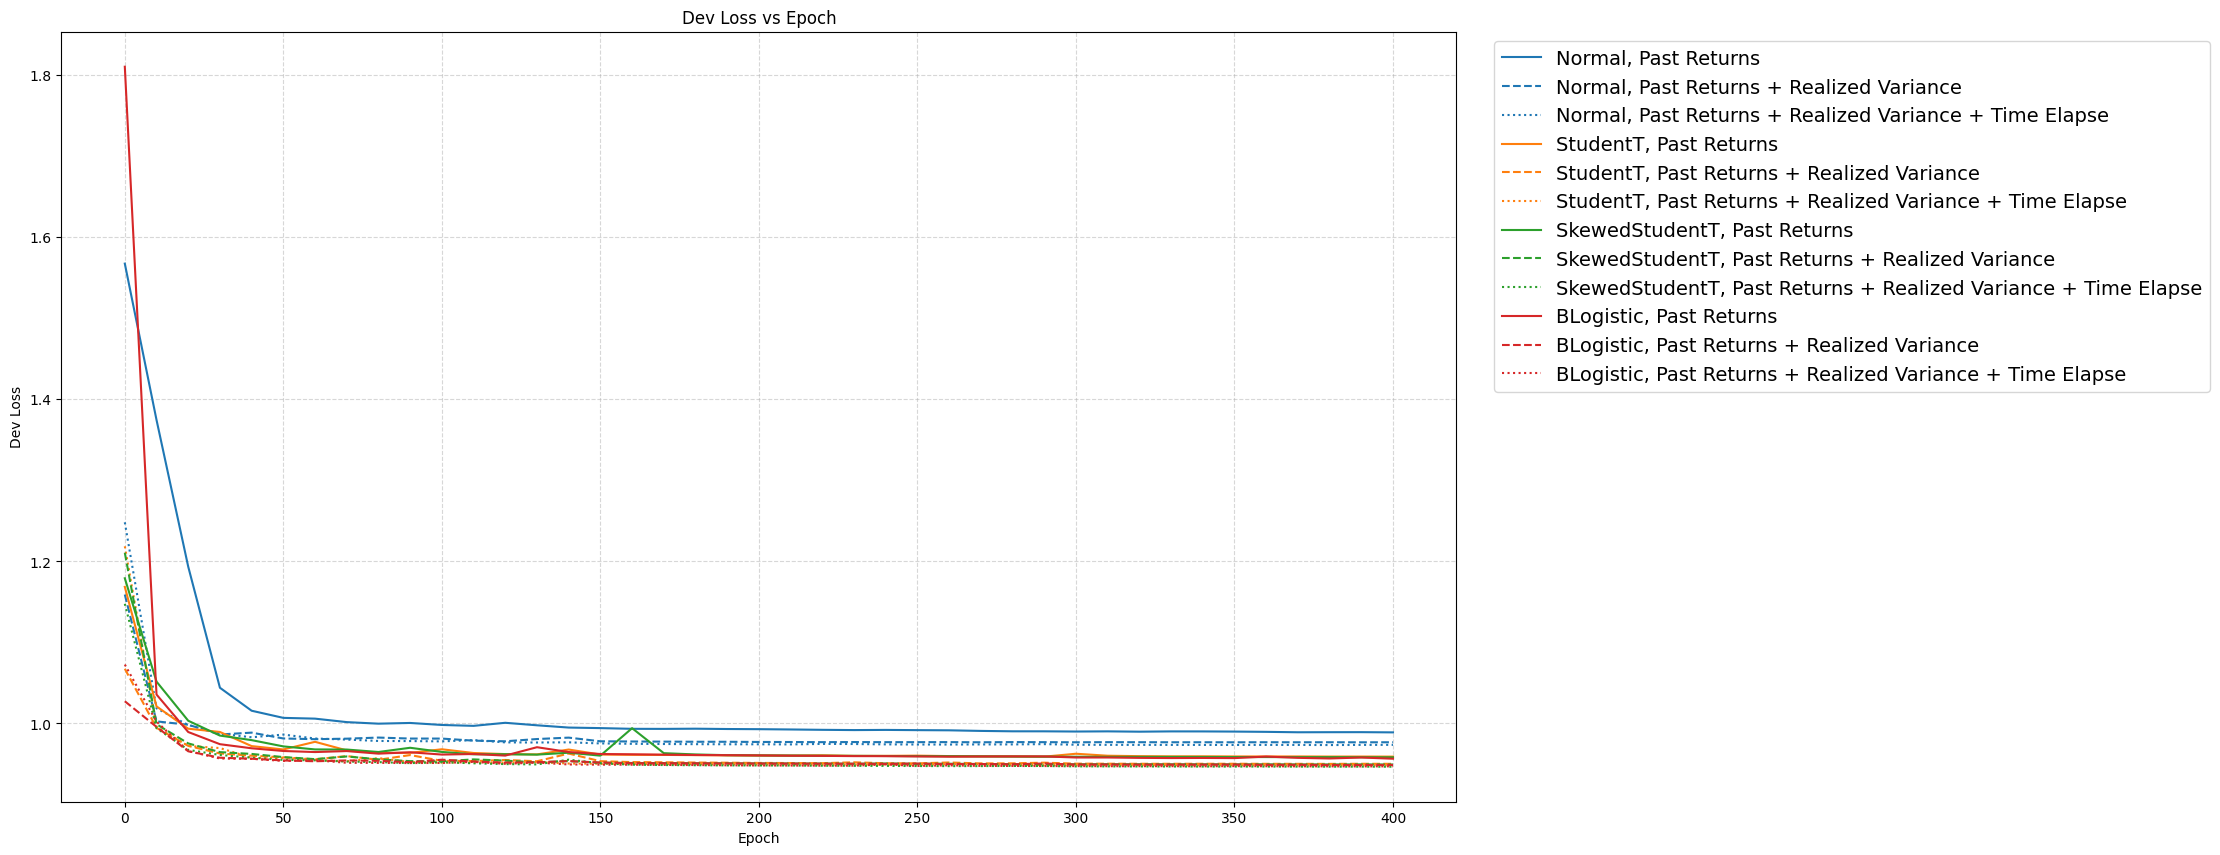

In [21]:
plt.figure(figsize=(18, 10))
plt.title("Dev Loss vs Epoch")

for (head, spec), df in results.items():
    color = color_map[head]
    style = style_map[spec]

    plt.plot(
        df["epoch"], df["dev_loss"],
        label=label_name(head, spec),
        color=color,
        linestyle=style
    )

plt.xlabel("Epoch")
plt.ylabel("Dev Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=14
)
plt.show()

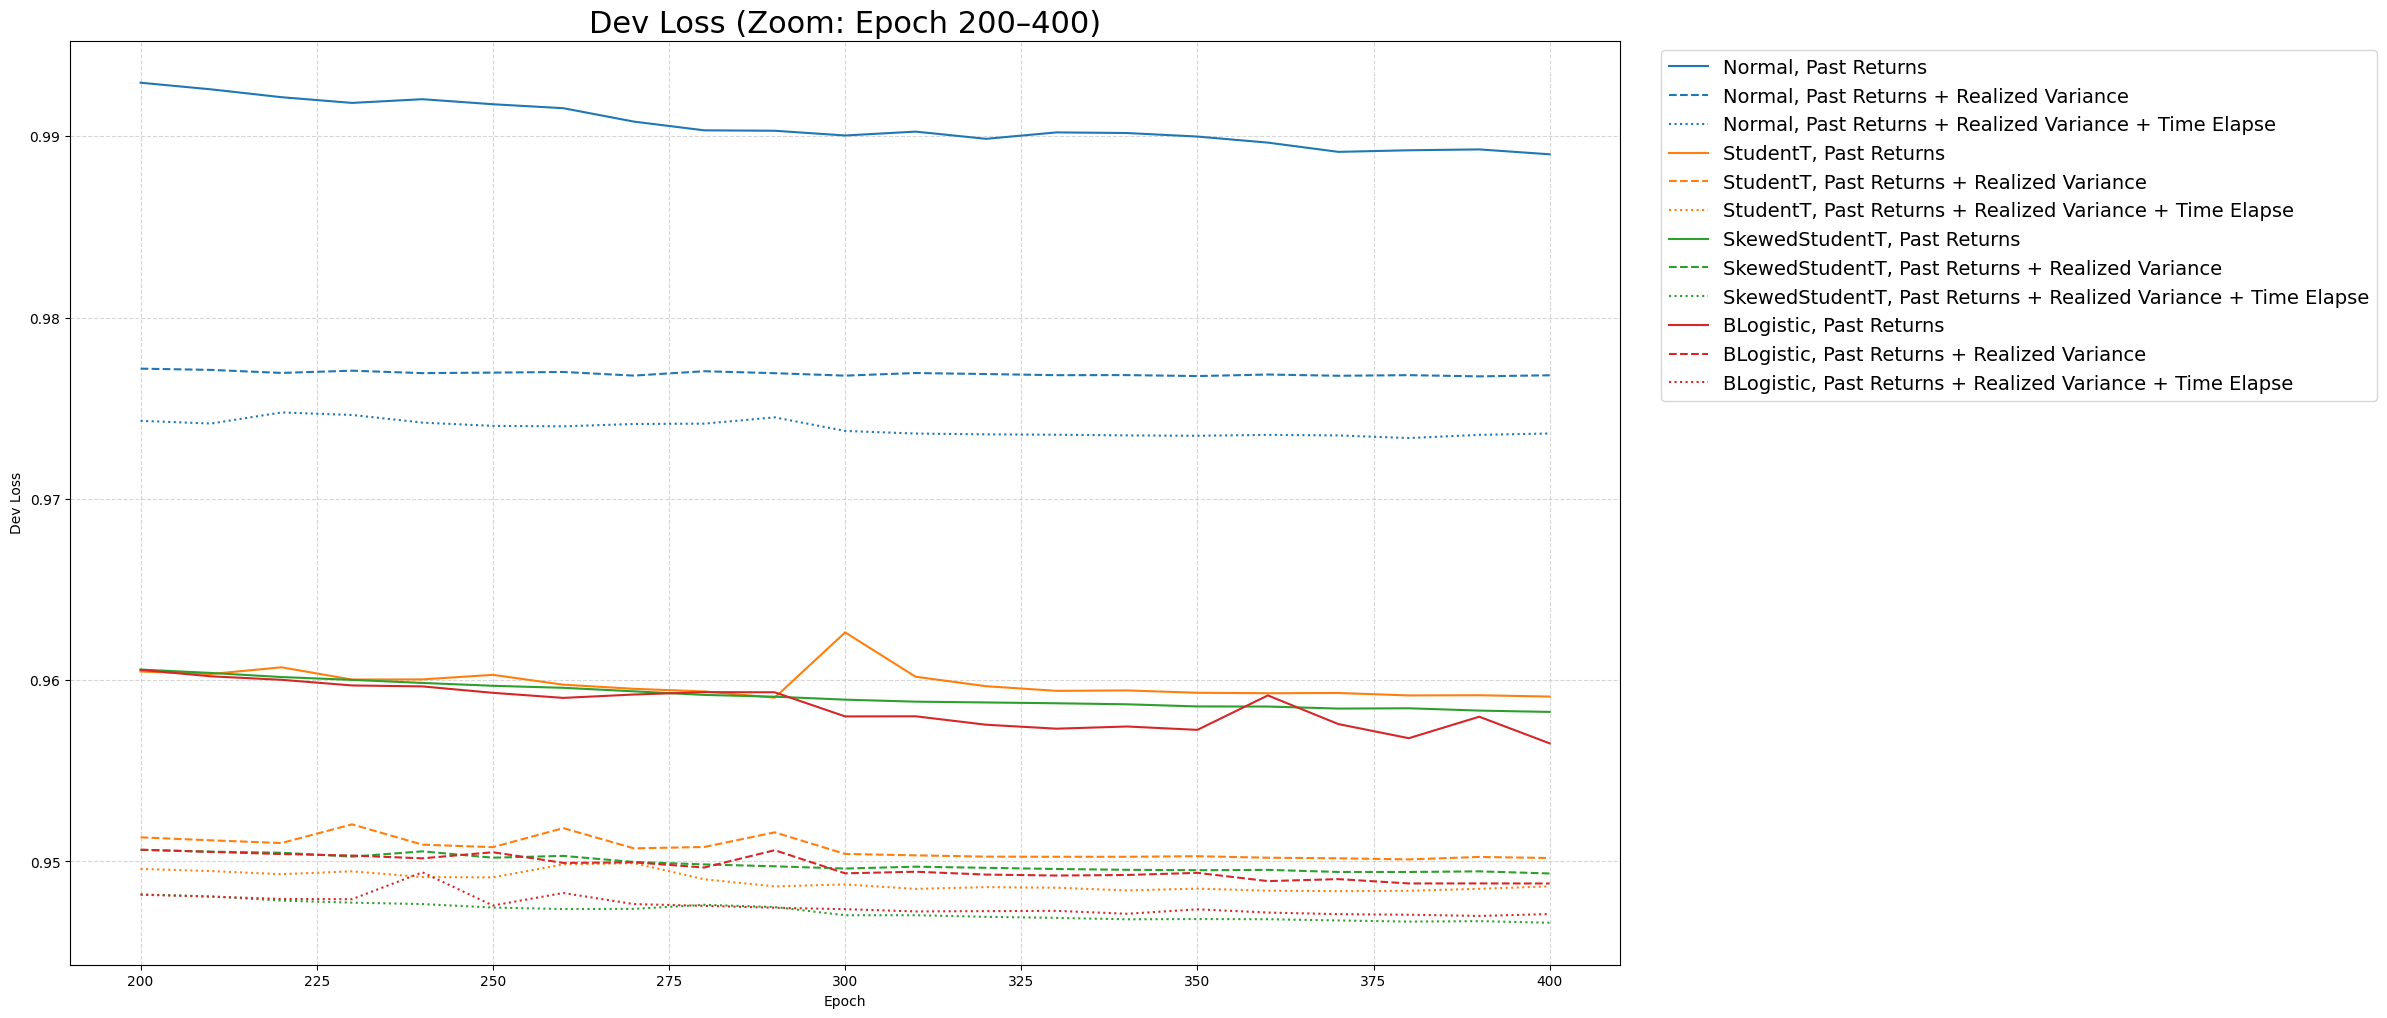

In [22]:
plt.figure(figsize=(20, 12))
plt.title("Dev Loss (Zoom: Epoch 200–400)", fontsize=22)

for (head, spec), df in results.items():
    color = color_map[head]
    style = style_map[spec]

    zoom_df = df[(df["epoch"] >= 200) & (df["epoch"] <= 400)]

    plt.plot(
        zoom_df["epoch"], zoom_df["dev_loss"],
        label=label_name(head, spec),
        color=color,
        linestyle=style
    )

plt.xlabel("Epoch")
plt.ylabel("Dev Loss")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    fontsize=14
)
plt.show()